# 3. Performance Comparison Lab: BST vs B-Tree — Disk Read Performance

**Duration: 10 minutes**

In this lab, you will experience firsthand why B-Trees are used in real-world databases instead of Binary Search Trees (BSTs).

The key question we explore:
> *Why does a B-Tree need far fewer disk reads than a BST to find the same record?*

---
**Lab Structure**

| Part | Topic | Time |
|------|-------|------|
| Part 1 | Environment Setup — simulating disk reads | 1–2 min |
| Part 2 | BST vs B-Tree — observe the performance gap | 3 min |
| Part 3 | Student Challenge — experiment & reflect | 5 min |

---
## Part 1: Environment Setup
### What is a "Disk Block" in a B-Tree?

In a **BST**, each node holds **one key**. Every comparison requires loading that single key from disk into RAM — one disk access per level.

In a **B-Tree of order m**, each node holds **up to m−1 keys**. One disk access loads the entire node — all its keys — into RAM at once.

> **Key insight:** Every time `read_disk_block()` is called in a B-Tree, we load a large node containing multiple keys all at once — unlike a BST, which loads only a single key per disk access.

We simulate a disk read using `time.sleep(0.1)` — a 100ms delay that mimics real hardware latency.

▶ **Run the cell below to set up the simulation environment.**

In [12]:
import time
import math
import matplotlib.pyplot as plt

# Simulate reading 1 block of data from disk (100ms hardware delay)
def read_disk_block():
    time.sleep(0.1)

# B-Tree simulation: calculates tree height and simulates disk reads
class BTreeSimulation:
    def __init__(self, m):
        self.m = m  # order of the B-Tree

    def get_height(self, num_elements):
        if num_elements <= 0:
            return 0
        if self.m == 2:  # BST equivalent
            return max(1, math.ceil(math.log2(num_elements)))
        ceil_m_half = math.ceil(self.m / 2)
        if ceil_m_half <= 1:
            return max(1, math.ceil(math.log2(num_elements)))
        return max(1, math.ceil(math.log((num_elements + 1) / 2, ceil_m_half) + 1))

    def search_simulation(self, num_elements):
        height = self.get_height(num_elements)
        start = time.time()
        for _ in range(height):
            read_disk_block()
        end = time.time()
        return height, end - start

print("Environment ready. Each disk read takes 0.1 seconds.")

Environment ready. Each disk read takes 0.1 seconds.


---
## Part 2: BST vs B-Tree — The Performance Gap

We search through a database of **100,000 records**.

- **Case A — BST (m = 2):** Each node holds 1 key. The tree grows tall → many disk reads.
- **Case B — B-Tree (m = 50):** Each node holds up to 49 keys. The tree stays flat → very few disk reads.

▶ **Run the cell and observe the difference.**

In [17]:
N = 100000
print("=== SEARCH SIMULATION: N = 100,000 records ===\n")

# Case A: BST (order m = 2)
bst_height = math.ceil(math.log2(N))
print(f"Case A — BST (m = 2, Height = {bst_height}):")
start_bst = time.time()
for _ in range(bst_height):
    read_disk_block()
end_bst = time.time()
print(f"  Disk reads : {bst_height}")
print(f"  Search time: {end_bst - start_bst:.2f} seconds\n")

# Case B: B-Tree (order m = 50)
btree_sim = BTreeSimulation(m=50)
b_height, b_time = btree_sim.search_simulation(N)
print(f"Case B — B-Tree (m = 50, Height = {b_height}):")
print(f"  Disk reads : {b_height}")
print(f"  Search time: {b_time:.2f} seconds\n")

print(f"=> B-Tree is {(end_bst - start_bst) / b_time:.1f}x faster with {bst_height - b_height} fewer disk reads.")

=== SEARCH SIMULATION: N = 100,000 records ===

Case A — BST (m = 2, Height = 17):
  Disk reads : 17
  Search time: 1.70 seconds

Case B — B-Tree (m = 50, Height = 5):
  Disk reads : 5
  Search time: 0.50 seconds

=> B-Tree is 3.4x faster with 12 fewer disk reads.


---
## Part 3: Student Challenge

### Step 1 — Experiment with different values of m

Change `m_student` to **3, 5, 10, and 100** one at a time and rerun the cell each time.
Watch how the **tree height** and **search time** change.

| m | Expected Height (N=100,000) |
|---|---|
| 2 (BST) | ~17 |
| 3 | ~11 |
| 5 | ~8 |
| 10 | ~6 |
| 50 | ~5 |
| 100 | ~4 |

In [15]:
# TO DO: Change the value of m_student below and rerun this cell
m_student = 3   # <-- try 3, 5, 10, 100

btree_student = BTreeSimulation(m=m_student)
h_student, t_student = btree_student.search_simulation(100000)

print(f"[YOUR RESULTS] B-Tree with order m = {m_student}")
print(f"  Tree height  : {h_student} levels")
print(f"  Disk reads   : {h_student} times")
print(f"  Search time  : {t_student:.2f} seconds")

[YOUR RESULTS] B-Tree with order m = 3
  Tree height  : 17 levels
  Disk reads   : 17 times
  Search time  : 1.70 seconds


### Step 2 — Visualize the Results

▶ **Run the cell below** to plot how tree height and search time change as m increases.

Running simulation, please wait...
  m =   2 | Height = 16 | Time = 1.60s
  m =   3 | Height = 16 | Time = 1.60s
  m =   5 | Height = 11 | Time = 1.10s
  m =  10 | Height =  8 | Time = 0.80s
  m =  50 | Height =  5 | Time = 0.50s
  m = 100 | Height =  4 | Time = 0.40s


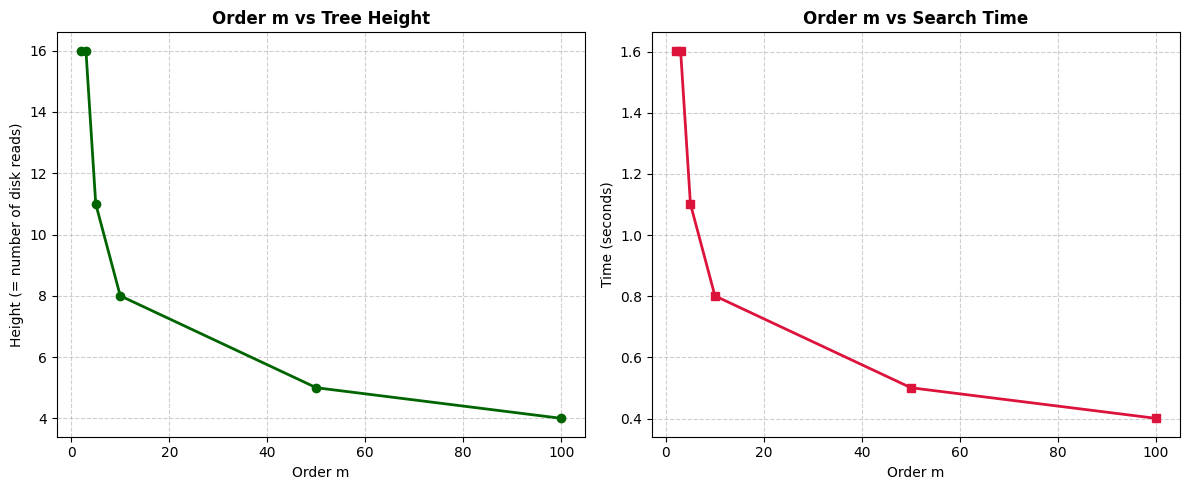

In [16]:
N_records = 50000
orders = [2, 3, 5, 10, 50, 100]
heights = []
times   = []

print("Running simulation, please wait...")
for m in orders:
    sim = BTreeSimulation(m)
    h, t = sim.search_simulation(N_records)
    heights.append(h)
    times.append(t)
    print(f"  m = {m:3d} | Height = {h:2d} | Time = {t:.2f}s")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(orders, heights, marker='o', linewidth=2, color='darkgreen')
plt.title('Order m vs Tree Height', fontsize=12, fontweight='bold')
plt.xlabel('Order m')
plt.ylabel('Height (= number of disk reads)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(orders, times, marker='s', linewidth=2, color='crimson')
plt.title('Order m vs Search Time', fontsize=12, fontweight='bold')
plt.xlabel('Order m')
plt.ylabel('Time (seconds)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Step 3 — Reflection Question

Think about the following question and write your answer in the cell below.

> **Q. When m is increased to an extremely large number (e.g., m = 1000 or m = 100,000), does the search time continue to decrease indefinitely? Why or why not?**
>
> *Hint: What happens to a single disk block when it has to hold thousands of keys at once? Think about memory and hardware constraints.*

**Your answer:**

*(Double-click this cell and write your response here.)*





---
### Summary

| | BST (m = 2) | B-Tree (m = 50) |
|---|---|---|
| Keys per node | 1 | up to 49 |
| Tree height (N=100K) | ~17 | ~5 |
| Disk reads | 17 | 5 |
| Search time | ~1.7 s | ~0.5 s |

A higher order m means each node stores more keys, the tree stays shallower, and fewer disk reads are needed — but only up to the point where a single node still fits efficiently into one disk block.